In [1]:
from mpasviewer import scvtmesh
from earthcmap import escmap

In [2]:
path2data = 'sample_data'
mpasd = scvtmesh(grid_file=f'{path2data}/nyc_static/nyc.static.nc', 
                 diag_list=f'{path2data}/nyc_out')

In [3]:
mpasd.dataset(load_variables=['rainnc', 'rainc', 'precipw', 't2m', 'uzonal'])

Loaded grid_file dataset: sample_data/nyc_static/nyc.static.nc


In [4]:
mpasd.rain_rate()

In [5]:
dta = mpasd.load()

In [6]:
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]
# print(*times, sep = ", ")

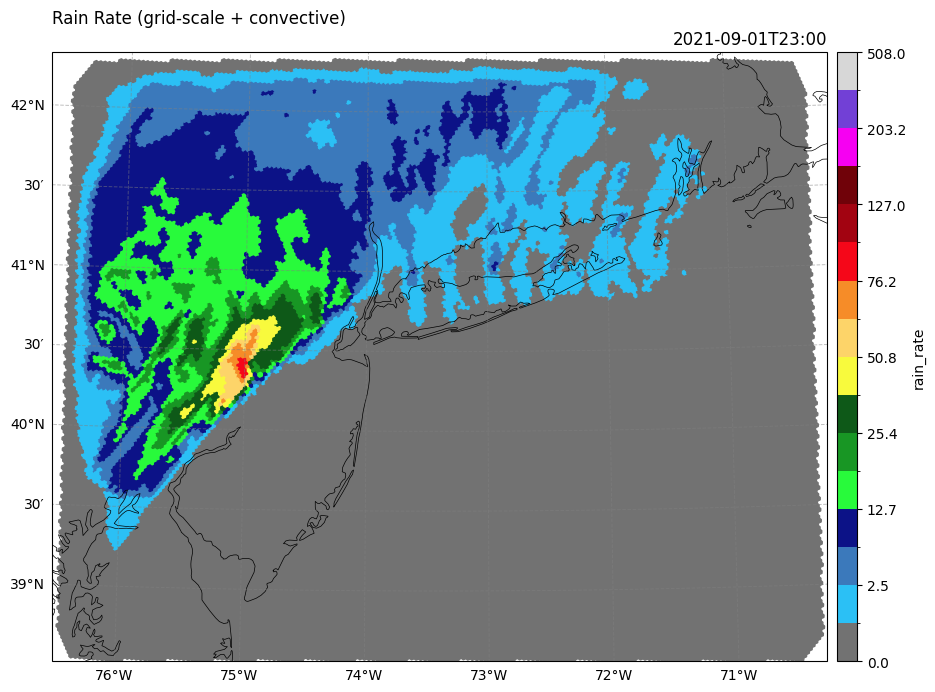

In [9]:
cmap, norm = escmap("nwps_qpe", units="mm")
mpasd.show(dta,var_name='rain_rate',time_index='2021-09-01T23', cmap = cmap, norm = norm, figsize = (10, 10))

In [10]:
cellid = mpasd.latlon2cellid(lon = -73.898, lat = 40.672)
print(cellid)

23160


In [11]:
pt0 = dta['rain_rate'].sel(face = cellid)

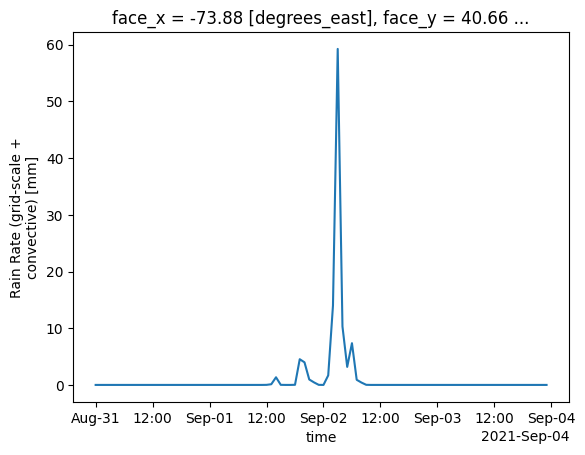

In [12]:
pt0.plot()

In [13]:
pt1 = dta['t2m'].sel(face = cellid)

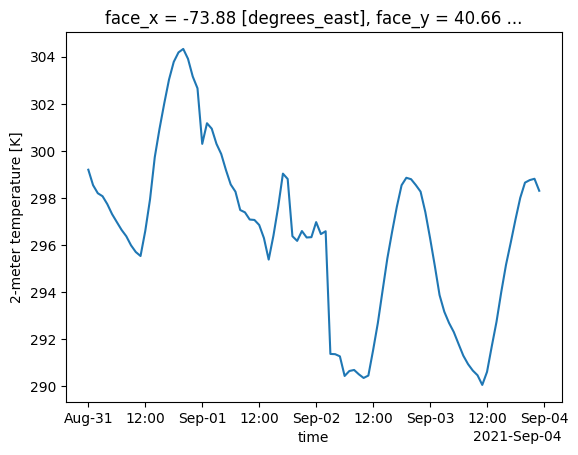

In [14]:
pt1.plot()

In [15]:
profile = dta['uzonal'].sel(face = cellid)#.to_dataframe()

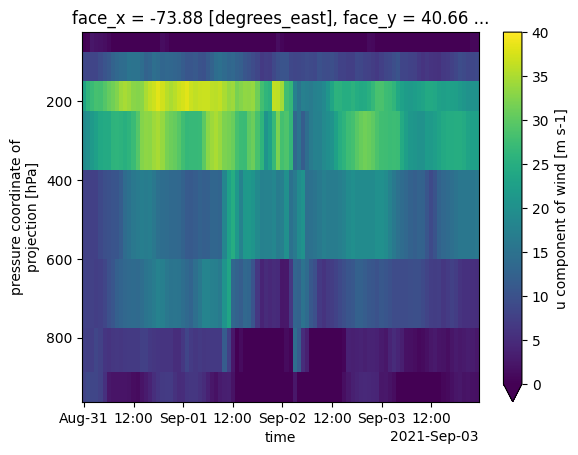

In [16]:
profile.plot(y = 'nPresLevels', yincrease = False, vmin = 0, vmax = 40)

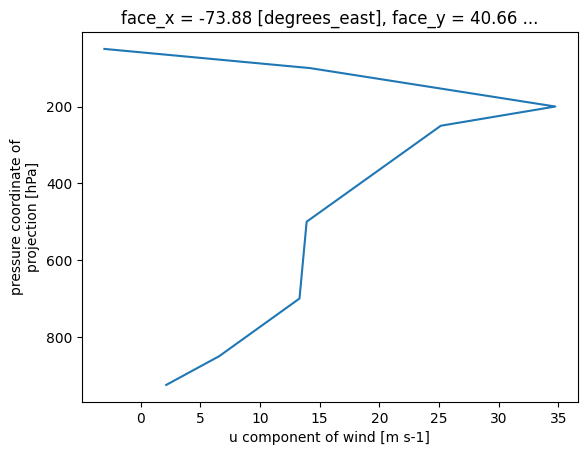

In [17]:
profile[10,:].plot(y = 'nPresLevels', yincrease = False)